# **Fundemental Statistics in Python**
## PyIU Advanced Python Workshop

Last modified: 11/19/2025

Author: Amelia Binau

What are the most fundemental functions and concepts in statistics that can be utilized using Python's vast library of packages? In this notebook, we'll review some statistics basics and relevant Python packages.

In [56]:
### general analysis packages
import numpy as np
import scipy as sp
import pandas as pd

### plotting packages
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['figure.dpi']=100
%config InlineBackend.figure_format='svg'

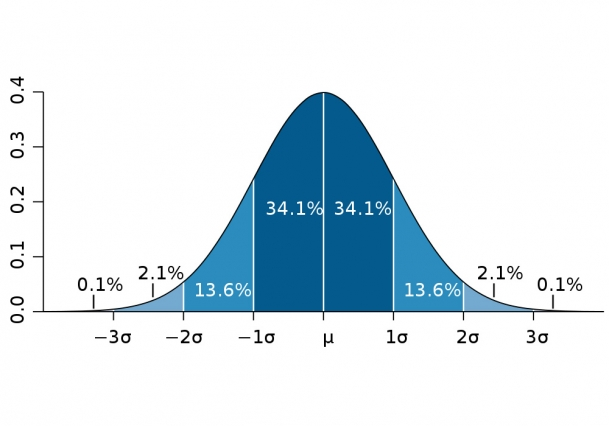

Let's start by creating a distribution of data, **randomly sampled from a Gaussian distribution around a mean**. Such a process is very common in physics, astronomy, psychology, etc. You may recognize that this process yeilds another **Gaussian or bell-curve distribution**.

This process can be done in a variety of Python packages, like much of statistics, but it is particularly simple in ``NumPy``, a basic package designed to make data analysis and manipulation simple. Let's generate a random Gaussian sample in ``NumPy``. For concreteness, it may be helpful to think of this random sample as test scores - we are saying some exam had a mean score of 70, a standard deviation of 20, and we are randomly sampling a finite distribution of random possible scores given these parameters. Let's sample 30 scores.

## $N = 30$

In [46]:
mean = 70 #Say the mean score is 70%.
std_dev = 15 #We have a decent spread in the data, 15 points for each standard deviation.
samples = 30 #Say there are 30 students in the class.

rand_distribution = np.random.normal(loc=mean, scale=std_dev, size=samples) #We are creating a list of data randomly sampled around a mean and standard deviation.

print(rand_distribution)

[ 75.86399159  93.57714957 100.82399684  47.62711647  88.64096192
  83.71083587  85.26882763  28.16231681  69.83705864  53.89002446
  77.67876429  69.32337961  74.57269884  62.80970811  70.88385184
  74.73775549  69.71007066  83.96856     64.42311997  98.79272544
  57.66278185  87.98462018  78.42554687  65.10216196  88.39995971
  67.22793974  92.08473344  80.23451785  66.92782999  59.32966682]


Let's create a plot using the ``Matplotlib`` package to visualize the data. You should find it has a rough bell-curve shape around our true mean.  

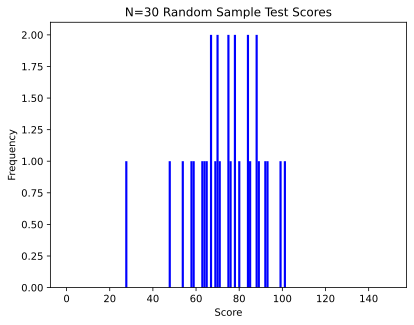

In [47]:
score_space = np.linspace(0, 150, 150) #We need to define an x-axis with a certain number of bins to plot our random sample against.
plt.hist(rand_distribution, score_space, color="blue")
plt.title('N=30 Random Sample Test Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

Let's verify that the mean and standard deviation of this random distribution is, in fact, what we said it was. Since ``np.random.normal`` is a random selection process that generates a finite distribution, we may find that the actual mean and standard deviation of the distribution are not exactly what we input. This is a fundemental property of randomly sampled distributions that follows the **Law of Large Numbers** -- the more we randomly sample, the more reflective of the true mean/standard deviation we can expect the distribtion to be of the true, realistics mean/standard deviation. The smaller the sample size, the higher the likelyhood for internal variation within our sampled distribution, and the less likely it is to reflect reality.

In [48]:
dist_mean = np.mean(rand_distribution)
dist_std_dev = np.std(rand_distribution)

print(f"The mean of our sampled distribution is {dist_mean}, while the standard deviation is {dist_std_dev}.")
print(f"The sampled mean is {abs(mean-dist_mean)} points away from the true mean, while the sampled standard deviation is {abs(std_dev-dist_std_dev)} point away.")

The mean of our sampled distribution is 73.9227557485778, while the standard deviation is 15.493103747371716.
The sampled mean is 3.9227557485777993 points away from the true mean, while the sampled standard deviation is 0.49310374737171614 point away.


What do you notice? Try rerunning the code box where we sampled the data, and rerun the box where we calculated the sample mean and standard deviation. Did the differences between the true parameters and sampled parameters change? Let's create a new random sample with a larger sample size - let's say there're 1000 students in the class that took the exam. Same mean and standard deviation.

## $N = 1000$

In [49]:
mean = 70 #Say the mean score is 70%.
std_dev = 15 #We have a decent spread in the data, 15 points for each standard deviation.
samples_bigger = 1000 #Say there are 30 students in the class.

larger_rand_distribution = np.random.normal(loc=mean, scale=std_dev, size=samples_bigger) #We are creating a list of data randomly sampled around a mean and standard deviation.

print(larger_rand_distribution[:10]) #Printing just the first 10 entries in the new, larger sample.

[61.5511     68.69576007 78.09104932 64.05969745 71.09286771 66.797335
 64.99048177 83.50934416 75.62576823 85.19751078]


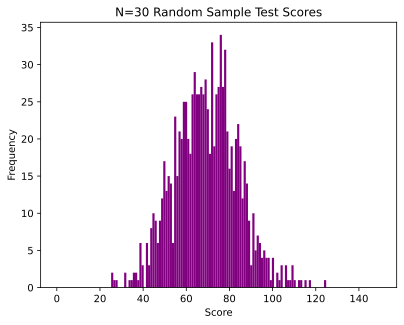

In [50]:
plt.hist(larger_rand_distribution, score_space, color="purple")
plt.title('N=30 Random Sample Test Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

Recalculate the sampled distribution's mean and standard deviation.

In [51]:
larger_dist_mean = np.mean(larger_rand_distribution)
larger_dist_std_dev = np.std(larger_rand_distribution)

print(f"The mean of our LARGER sampled distribution is {larger_dist_mean}, while the standard deviation is {larger_dist_std_dev}.")
print(f"The new, LARGER sampled mean is {abs(mean-larger_dist_mean)} points away from the true mean, while the LARGER sampled standard deviation is {abs(std_dev-larger_dist_std_dev)} points away.")

The mean of our LARGER sampled distribution is 69.38604385042906, while the standard deviation is 14.75627088940716.
The new, LARGER sampled mean is 0.6139561495709387 points away from the true mean, while the LARGER sampled standard deviation is 0.24372911059283986 point away.


### **Notice:** The larger our sample size, the smaller the difference between our sampled mean/standard deviation from their true values. This is the Law of Large Numbers.

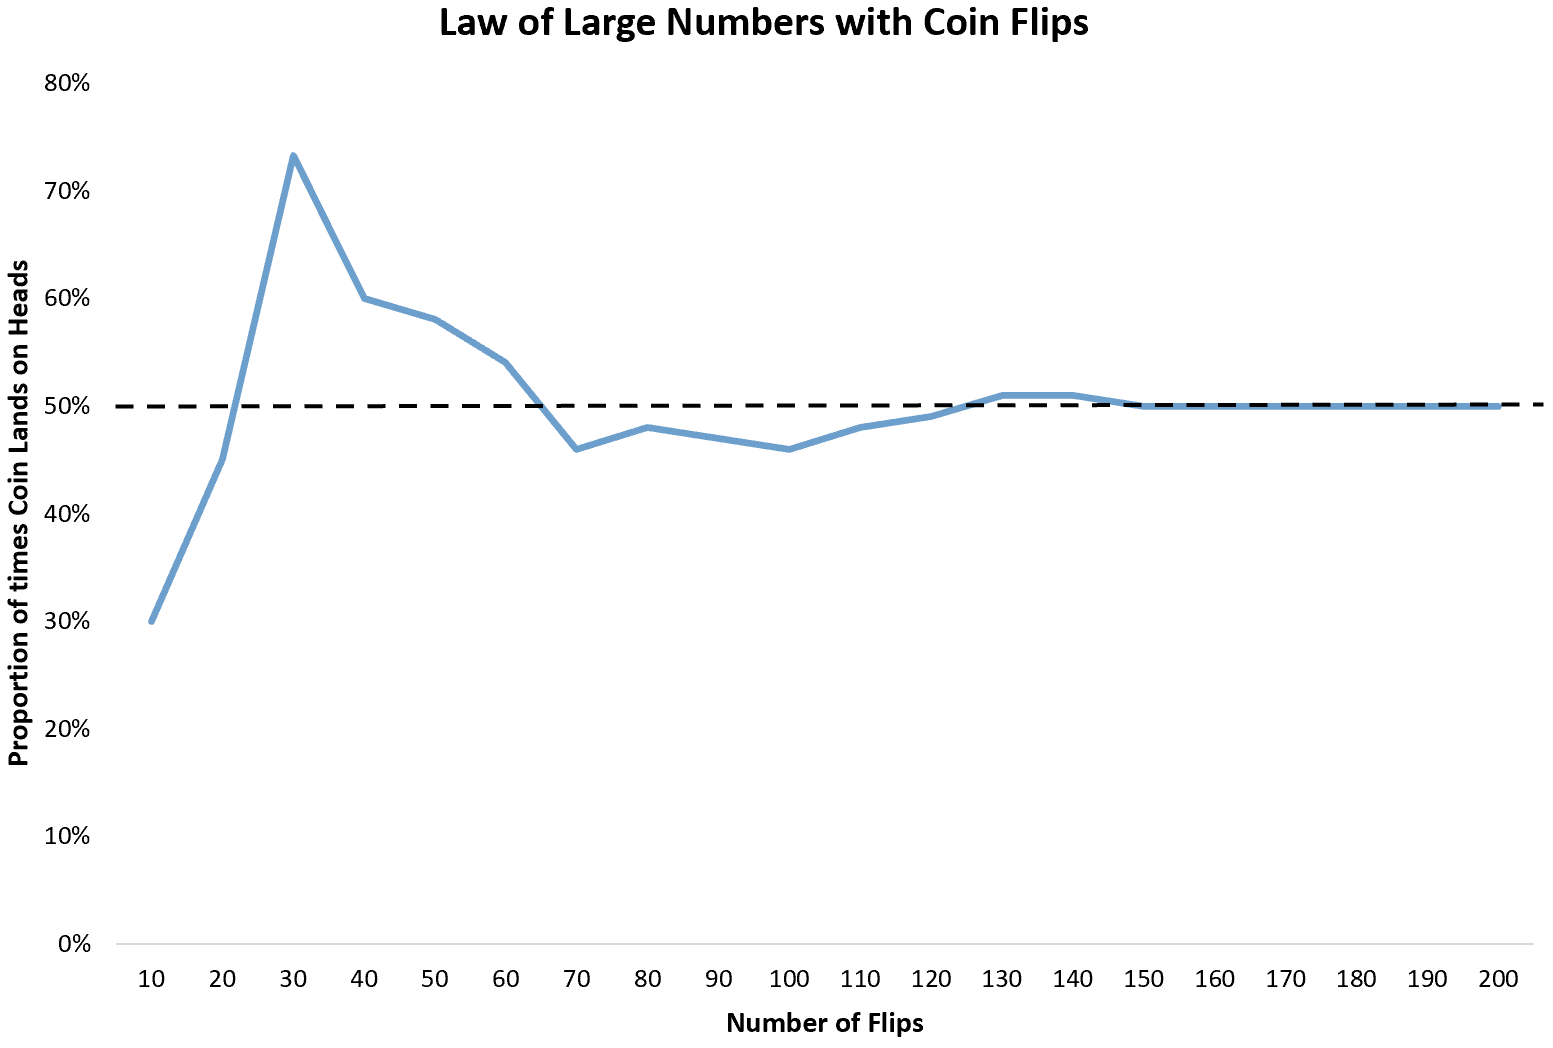

In Python, basic statistical functions such as mean, median, mode, and standard deviation, are spread across a variety of packages as well as the base Python language (without modification). For instance, let's say we want to compute the mean of a set of data. We could call **four** or more functions, one from the base Python module `statistics` ([Documentation](https://docs.scipy.org/doc/scipy-0.8.x/reference/generated/scipy.stats.mean.html)), one from ``SciPy`` ([Documentation](https://docs.python.org/3/library/statistics.html)), one from ``Pandas`` ([Documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html)), or one from the ``NumPy`` as we did above. All of these functions can be used fairly equivalently; it mostly comes down to what package you're familiar with, using consistently in your notebook, or what type of dataframe you're using. We'll continue by reviewing other statistical functions in ``NumPy``, but keep in mind the wide variety of packages in Python that can be used for statistical analyses.

We can use NumPy to calculate the median and quartiles of our random distributions, too.

In [53]:
median = np.median(larger_rand_distribution)
print(median)

69.3551690581894


In [55]:
q1 = np.quantile(larger_rand_distribution, 0.25)
q2 = np.quantile(larger_rand_distribution, 0.50)
q3 = np.quantile(larger_rand_distribution, 0.75)

print(f"q1 = {q1}, q2 = {q2} (same as the median!), q3 = {q3}")

q1 = 59.21010254432182, q2 = 69.3551690581894 (same as the median!), q3 = 79.06731781619658


Oftentimes, the median and quartiles is considered the most helpful statistical quantity at first glance, as compared to the mean. This is because it removes outliers that would normally heavily affect the mean and leave data that more accurately reflect the bulk of the data. It also helps encapsulate skewness in the data.

``NumPy``, as well as other packages, can compute other statistical functions, including maxs, mins, and correlation coefficients. More advanced statistical procedures, such as t-tests, ANOVA, and chi-squared regressions can also be constructed easily. Most of these more advanced functions are available in ``scipy.stats`` ([Documentation](https://docs.scipy.org/doc/scipy/reference/stats.html)).